In [3]:
from datasets import load_dataset, Dataset, load_from_disk
from transformers import AutoTokenizer, GPT2Config, T5Config

import math
import argparse
from tqdm import tqdm
import torch
import torch.nn as nn
import random
import os
import pickle
import re
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, SequentialSampler

from newModelsT5SimplifiedRpl import T5ModelDecoderCacheReplacer
from utilsLM import customTrainer, customCollator, process_wiki

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
tokenizer_name = 't5-small'

dataset = 'dog'
xl_cache_size = 128
fix_cache_size = 512

if dataset == 'dog':
    model_name = "..."
    data_path = f'./LMdatasets/processed-dog3-{tokenizer_name}-8-512-fix12'
    valid_batch_size = 4

elif dataset == 'pg19':
    model_name = "..."
    data_path = f'./LMdatasets/processed-{tokenizer_name}-32-512-fix12'
    valid_batch_size = 8

elif dataset == 'wiki':
    model_name = "..."
    data_path = f'./LMdatasets/processed-wiki2-{tokenizer_name}-32-512-fix12'
    valid_batch_size = 8

tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, cache_dir='./cache/models', model_max_length=2048)


print('loading dataset...')
tokenized_dataset = load_from_disk(data_path)

# config = T5Config.from_pretrained(model_name)
model = T5ModelDecoderCacheReplacer.from_pretrained(model_name, block_size=512, xl_cache_size=128, fix_cache_size=512, \
                                     selector_cache_size=128, \
                                    selector_cache_num=3, tokenizer=tokenizer)

block_size = 512

tokenizer.pad_token = tokenizer.eos_token

data_collator = customCollator(tokenizer=tokenizer)

valid_dataset = tokenized_dataset["validation"]
valid_loader = DataLoader(
            valid_dataset,
            sampler=SequentialSampler(valid_dataset),
            batch_size=valid_batch_size,
            collate_fn=data_collator
        )



loading dataset...
params:	 xl_cache 128 fix_cache 512 selector 128 3


In [2]:
with torch.no_grad():
    step_num = 10
    model.to(device)
    model.reset_cache(valid_batch_size)
    model.eval()
    
    count = 0
    for inputs in tqdm(valid_loader):
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        count += 1
        if count > step_num:
            break
   

empty cache...


  1%|          | 10/1088 [00:03<05:52,  3.06it/s]


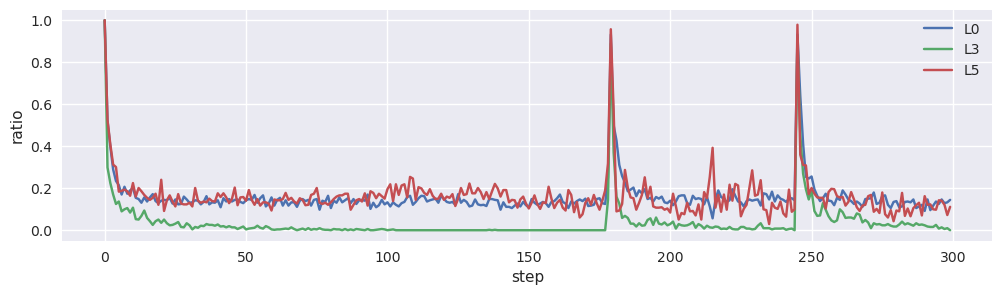

In [5]:
from matplotlib import pyplot as pyplot
import numpy as np
# plt.style.use('ggplot')
plt.style.use('seaborn-v0_8')
batch_idx = 4
show_len = 300
fig, ax = plt.subplots()
fig.set_size_inches(12, 3)
ax.plot(np.array(model.decoder.block[0].layer[0].SelfAttention.select_curve['cuda:0'].cpu()[batch_idx, :show_len]), label='L0')
ax.plot(np.array(model.decoder.block[3].layer[0].SelfAttention.select_curve['cuda:0'].cpu()[batch_idx, :show_len]), label='L3')
ax.plot(np.array(model.decoder.block[5].layer[0].SelfAttention.select_curve['cuda:0'].cpu()[batch_idx, :show_len]), label='L5')
ax.legend()
ax.set_xlabel('step')
ax.set_ylabel('ratio')
# print(model.decoder.block[5].layer[0].SelfAttention.select_curve['cuda:0'][:100])
plt.show()

In [5]:
from IPython.core.display import display, HTML
def highlighter(word, value):
    return '<span style="background-color:rgba(40,156,206,%.2f)">'%(value) +word+ '</span>' 

layer_idx = 5
batch_idx = 2
info = model.decoder.block[layer_idx].layer[0].SelfAttention.pass_info

to_fix_ids = info[f'{batch_idx}-to_fix_ids'].tolist()
old_ids = info[f'{batch_idx}-old_ids'].tolist()

mask = info[f'{batch_idx}-mask'].float().tolist()

to_fix_tokens = list(map(lambda t: t.replace('▁', ' '), tokenizer.convert_ids_to_tokens(to_fix_ids)))
old_tokens = list(map(lambda t: t.replace('▁', ' '), tokenizer.convert_ids_to_tokens(old_ids)))

table_html = f'<span style="background-color:rgba(246,106,100, 1.0)"> Layer {layer_idx}: </span>'


row_num = 20
col_num = len(to_fix_tokens)// row_num + 1

for j in range(row_num):
    row_m = mask[j*col_num:(j+1)*col_num]
    table_html += '<table width="1" style="border: 0px">'
    row_html = '<td style="font-size: 12px"> <b> cache </b></td>' + ' '.join([f'<td width="1" style="font-size: 12px; border: 0px; padding-top: 10px; background-color:rgba(253,255,50, {1-m})">{t}</td>' for m,t in zip(row_m,old_tokens[j*col_num:(j+1)*col_num])])
    row_html = '<tr>' + row_html + '</tr>'
    table_html += row_html
    row_html = '<td style="font-size: 12px"> <b> new </b></td>' + ' '.join([f'<td width="1" style="font-size: 12px; border: 0px; background-color:rgba(253,255,50, {m})">{t}</td>' for m,t in zip(row_m, to_fix_tokens[j*col_num:(j+1)*col_num])])
    row_html = '<tr>' + row_html + '</tr>'
    table_html += row_html

    table_html += '</table>'

display(HTML(table_html))


/tmp/ipykernel_3526620/756133175.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


cache,shops,districts,wash,e,e,,,s,1930,mad,river,"""",@,Country,Music,member,districts,Register,of,Historic,Place,s,quit,ted,Highland,Park
new,",",@,000,people,,.,"""",The,East,Mississippi,Correction,al,Facility,is,located,in,un,incorporated,Lauderdale,County,,",",near,Meridian,,.
cache,Downtown,Historic,District,city,19,13,trial,Union,Station,dale,districts,built,Rag,s,dale,City,Center,Historic,District,Main,Street,er,Station,Historic,District,@
new,It,is,operated,by,the,G,EO,Group,on,behalf,of,the,Mississippi,Department,of,Correction,s,,.,The,chief,of,the,Meridian,Fire,Department
cache,government,and,,=,and,council,Railroad,Meridian,Transit,System,,2005,Grey,hound,Bus,e,s,t,zel,Car,ous,ways,l,e,e,""""
new,is,Anthony,Clayton,,.,The,fire,department,responded,to,more,than,1600,calls,in,2009,,",",including,,123,structural,fire,s,and,6
cache,Anne,budget,",",Colonial,,i,Hall,,",",Italian,ate,Edgar,Ray,Kill,en,Kre,s,s,Late,&,Co,l,aught,er,ung,a
new,09,emergency,service,calls,,.,,The,Mississippi,Department,of,Mental,Health,operates,the,East,Mississippi,State,Hospital,in,Meridian,,.,,The,United
cache,low,1,23,Southern,and,Avenue,Grand,Avenue,,1,East,End,1986,c,y,kin,nd,,James,Cha,ney,Theater,–,Avenue,10,Dr
new,States,Post,al,Service,operates,the,Meridian,,",",North,Meridian,,",",and,the,West,Meridian,Station,post,offices,,.,,In,state,politics
cache,11,George,M,.,Thomas,,th,St,,Ward,1,Station,Ave,Kenne,th,Dust,in,Mark,ham,ve,y,representative,from,Ave,2,


In [6]:
table_html

'<span style="background-color:rgba(246,106,100, 1.0)"> Layer 5: </span><table width="1" style="border: 0px"><tr><td style="font-size: 12px"> <b> cache </b></td><td width="1" style="font-size: 12px; border: 0px; padding-top: 10px; background-color:rgba(253,255,50, 1.0)"> shops</td> <td width="1" style="font-size: 12px; border: 0px; padding-top: 10px; background-color:rgba(253,255,50, 1.0)"> districts</td> <td width="1" style="font-size: 12px; border: 0px; padding-top: 10px; background-color:rgba(253,255,50, 1.0)">wash</td> <td width="1" style="font-size: 12px; border: 0px; padding-top: 10px; background-color:rgba(253,255,50, 1.0)">e</td> <td width="1" style="font-size: 12px; border: 0px; padding-top: 10px; background-color:rgba(253,255,50, 1.0)">e</td> <td width="1" style="font-size: 12px; border: 0px; padding-top: 10px; background-color:rgba(253,255,50, 1.0)"></s></td> <td width="1" style="font-size: 12px; border: 0px; padding-top: 10px; background-color:rgba(253,255,50, 1.0)"></s></t

In [39]:
from IPython.core.display import display, HTML
def highlighter(word, value):
    return '<span style="background-color:rgba(40,156,206,%.2f)">'%(value) +word+ '</span>' 



layer_idx = 5
batch_idx = 1
info = model.decoder.block[layer_idx].layer[0].SelfAttention.pass_info

to_fix_h = info['to_fix_h']
to_fix_ids = info['to_fix_ids']

for t in [1, 20, 100]:
    input_t = torch.full((to_fix_h.size(0), to_fix_h.size(1), 1), t, device=to_fix_h.device) * model.decoder.block[layer_idx].layer[0].SelfAttention.t_emb.view(1,1,-1)
    score = model.decoder.block[layer_idx].layer[0].SelfAttention.replacer(torch.cat([to_fix_h, input_t], dim=-1)).squeeze(-1)

    tokens = tokenizer.convert_ids_to_tokens(to_fix_ids[batch_idx, 0, 100:200].tolist())
    token_scores = score[batch_idx, 100:200].tolist()

    # print(min(token_scores), max(token_scores))
    html = f'<div style="margin-bottom:5px"> <span style="background-color:rgba(246,106,100, 1.0) "> &Delta; t = {t}: </span> <span> &nbsp; min: {min(token_scores):.2f} &nbsp; max: {max(token_scores):.2f} </span> </div>'
    html = html + ''.join([highlighter(token.replace('▁', ' '), s/15) for s, token in zip(token_scores, tokens)])

    display(HTML(html))

/tmp/ipykernel_3536217/1392994364.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [3]:


model.to(device)
model.eval()
model.reset_cache(valid_batch_size)
for inputs in tqdm(valid_loader):
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)

for i in range(model.config.num_layers):
    first_select_num = model.decoder.block[i].layer[0].SelfAttention.first_select_num['cuda:0']
    total_num = model.decoder.block[i].layer[0].SelfAttention.total_num['cuda:0']
    print('layer ', i)
    print(first_select_num/total_num)

empty cache...


 22%|██▏       | 238/1088 [00:55<03:20,  4.23it/s]

tensor([  22.,  239., 1134., 2222.,  479.]) tensor([-9.8698, -7.3764, -4.8830, -2.3897,  0.1037,  2.5971])
layer: 0 mean log alpha: -1.798887014389038 std log alpha: 1.8113089799880981 select ratio: 0.14501953125
|t <.> |wig <▁And> |▁ <▁And> |<unk> <▁of> |17 <▁Saturn> |> <*> |▁A <▁And> |▁ <.> |mer <▁kid> |ry <▁or> |<▁child> ▁of |<▁> ▁Kent |he <,> |▁was <▁or> |<,> ▁his |▁so <▁serie> |▁God <▁And> |▁me <.> |▁save <.> |; <.> |▁Well <.> |▁could <.> |▁ <Hence> |he <▁brake> |▁let <▁or> |ten <,> |▁blood <▁And> |, <.> |▁and <▁shall> |▁clip <▁or> |, <▁And> |▁and <.> |▁ <.> |s <ological> |have <▁husband> |, <▁Saturn> |<▁And> ▁And |▁make <.> |▁ <▁of> |a <▁jealous> |▁charter <e> |<▁of> ▁wife |▁land <▁Of> |, <▁and> |<▁and> * |▁ <.> |a <▁memories> |▁quit <e> |t <▁And> |ance <e> |<.> ▁necessity |▁In <.> |▁twenty <▁and> |<▁manner> e |s <▁And> |▁could <▁fabulous> |▁ <,> |he <.> |▁trip <*> |<▁and> ▁Nicholas |▁dance <▁ladies> |, <.> |▁After <▁Roman> |▁the <,> |<▁school> , |<▁of> , |▁Ox <▁Of> |en <▁hence> 

 48%|████▊     | 518/1088 [02:03<02:21,  4.02it/s]

tensor([  64.,  628., 1576., 1548.,  280.]) tensor([-11.8831,  -8.5568,  -5.2305,  -1.9042,   1.4222,   4.7485])
layer: 2 mean log alpha: -2.4598326683044434 std log alpha: 2.7252373695373535 select ratio: 0.201904296875
|▁and <▁strong> |▁every <▁> |▁so <hou> |re <▁> |<▁Sha> ▁Wright |ll <ppy> |▁every <.> |▁sheep <▁> |▁be <▁Dor> |▁whole <▁> |, <▁> |▁that <▁> |▁of <▁> |▁this <▁And> |▁well <▁> |▁Drink <▁> |<e> ▁39 |<th> ▁pre |<▁> late |a <▁Pro> |▁ <logue> |d <▁> |<r> ▁Ro |aught <▁> |; <▁> |▁take <▁> |▁keep <▁> |* <▁> |▁of <Trans> |▁that <▁> |▁I <▁> |▁tell <▁> |. <bal> |▁* <▁> |heed <▁> |▁" <▁> |If <▁> |▁that <▁scene> |▁the <ball> |<▁good> ▁pilgrim |<man> . |, <▁> |▁that <cer> |▁the <ight> |<▁beast> ▁ |<e> ▁ |s <▁lang> |<▁> ▁front |ow <▁of> |e <.> |th <▁> |, <n> |* <hou> |▁* <us> |own <▁> |<e> don |th <▁> |▁Will <d> |▁every <▁and> |<▁week> ▁be |, <▁> |▁ <▁> |er <me> |e <us> |▁that <▁> |▁the <▁> |<▁> ▁and |cock <▁> |▁him <▁and> |<▁> ▁confession |<cro> ▁of |we <▁> |th <▁> |, <▁> |▁Fast <▁> |

 66%|██████▌   | 713/1088 [02:51<01:32,  4.04it/s]

tensor([  62.,  515., 1535., 1638.,  346.]) tensor([-12.1780,  -8.8496,  -5.5211,  -2.1927,   1.1357,   4.4642])
layer: 2 mean log alpha: -2.4760522842407227 std log alpha: 2.706484794616699 select ratio: 0.195068359375
|▁sin <▁> |s <▁> |▁which <e> |▁many <▁and> |<▁> ▁corrupt |a <.> |<▁man> ; |▁per <▁> |a <▁> |<d> e |vent <▁> |<ure> ▁of |▁ <▁> |deem <▁> |s <▁Par> |▁no <▁trans> |▁sin <▁> |s <▁> |, <▁> |▁and <▁> |<▁confess> worm |e <▁> |s <▁> |▁them <▁> |▁not <▁> |, <▁virtue> |<▁and> s |<▁yet> ▁penalty |▁nevertheless <▁> |▁they <▁> |▁are <▁and> |▁truly <▁> |▁sin <▁> |s <c> |: <▁wo> |▁-- <▁> |▁ <▁> |] <Isaiah> |▁This <.> |▁is <man> |▁to <with> |▁say <c> |, <▁> |▁at <▁of> |▁every <▁sin> |▁time <rea> |▁that <▁> |<▁> ▁also |a <▁> |▁man <e> |▁ <▁> |e <.> |ate <▁> |th <ordained> |▁and <▁> |▁drink <▁> |<e> ▁mean |th <▁> |▁more <▁> |▁than <▁cert> |<▁suffi> e |ce <▁> |<th> ▁Al |▁to <▁co> |▁the <▁> |<▁sus> t |ten <▁> |ance <hou> |▁of <▁> |▁his <▁> |<▁body> ▁therefore |, <.> |▁in <▁> |▁certain <▁> 

100%|██████████| 1088/1088 [04:20<00:00,  4.17it/s]

layer  0
-0.09791824063568404
layer  1
-0.17786541989430635
layer  2
-0.5669889547553955
layer  3
0.07147380148115404
layer  4
-0.2708315051619566
layer  5
-0.3305338544271174
layer  6
-0.9714536193847273
layer  7
0.08269067463783465
